In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Makes charts look cleaner
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

In [ ]:
orders     = pd.read_csv('/content/drive/MyDrive/eda/olist_orders_dataset.csv')
order_items = pd.read_csv('/content/drive/MyDrive/eda/olist_order_items_dataset.csv')
customers  = pd.read_csv('/content/drive/MyDrive/eda/olist_customers_dataset.csv')
products   = pd.read_csv('/content/drive/MyDrive/eda/olist_products_dataset.csv')
payments   = pd.read_csv('/content/drive/MyDrive/eda/olist_order_payments_dataset.csv')
reviews    = pd.read_csv('/content/drive/MyDrive/eda/olist_order_reviews_dataset.csv')
sellers    = pd.read_csv('/content/drive/MyDrive/eda/olist_sellers_dataset.csv')
category_translation = pd.read_csv('/content/drive/MyDrive/eda/product_category_name_translation.csv')

In [ ]:
print("\n" + "="*50)
print("ORDERS TABLE")
print("="*50)
print(f"Shape: {orders.shape}")       # How many rows & columns?
print("\nColumn Types:")
print(orders.dtypes)
print("\nMissing Values:")
print(orders.isnull().sum())
print("\nFirst 3 rows:")
orders.head(3)


ORDERS TABLE
Shape: (99441, 8)

Column Types:
order_id                         object
customer_id                      object
order_status                     object
order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object
dtype: object

Missing Values:
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

First 3 rows:


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00


In [ ]:
# PHASE 2: DATA CLEANING

date_columns = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_columns:
    orders[col] = pd.to_datetime(orders[col])

print("Date columns fixed!")
print(orders[date_columns].dtypes)  # Should now show datetime64

# ---- Step 2: Check Order Status Distribution ----
# Before filtering, let's see what statuses exist
# value_counts() counts how many rows have each unique value

print("\nOrder Status Breakdown:")
print(orders['order_status'].value_counts())
print(f"\nTotal orders: {len(orders)}")

# ---- Step 3: Filter to Delivered Orders Only ----
# For sales/revenue analysis, we only want COMPLETED orders
# Cancelled, unavailable orders should not count as real sales
# This is a business decision — and explaining it shows maturity!

delivered_orders = orders[orders['order_status'] == 'delivered'].copy()

print(f"\nDelivered orders: {len(delivered_orders)}")
print(f"   Removed: {len(orders) - len(delivered_orders)} non-delivered orders")

# ---- Step 4: Create Useful Time Columns ----
# We extract month/year from the purchase date
# This lets us later ask: "How did sales change each month?"

delivered_orders['order_month'] = delivered_orders['order_purchase_timestamp'].dt.to_period('M')
delivered_orders['order_year']  = delivered_orders['order_purchase_timestamp'].dt.year
delivered_orders['order_month_num'] = delivered_orders['order_purchase_timestamp'].dt.month

print("\nTime columns created!")
print(delivered_orders[['order_purchase_timestamp', 'order_month', 'order_year']].head(3))

# ---- Step 5: Calculate Delivery Time ----
# This is a GREAT insight column — how long did delivery actually take?
# Subtracting two datetime columns gives us a timedelta (duration)
# .dt.days converts that to a simple integer number of days

delivered_orders['delivery_days'] = (
    delivered_orders['order_delivered_customer_date'] -
    delivered_orders['order_purchase_timestamp']
).dt.days

print("\nDelivery Time Stats (days):")
print(delivered_orders['delivery_days'].describe().round(1))

# ---- Step 6: Merge All Tables Into One Master Table ----
# Right now revenue info is in order_items, customer info in customers, etc.
# We JOIN them using common keys (like order_id) — same concept as SQL JOIN

# Step 6a: Merge orders + order_items (link by order_id)
df = delivered_orders.merge(order_items, on='order_id', how='inner')
print(f"\nAfter merging with order_items: {df.shape}")

# Step 6b: Merge with payments to get payment method info
payments_agg = payments.groupby('order_id').agg(
    total_payment=('payment_value', 'sum'),
    payment_type=('payment_type', 'first'),
    installments=('payment_installments', 'max')
).reset_index()
df = df.merge(payments_agg, on='order_id', how='left')
print(f"After merging with payments: {df.shape}")

# Step 6c: Merge with products + category translation
products_merged = products.merge(category_translation, on='product_category_name', how='left')
df = df.merge(products_merged[['product_id', 'product_category_name_english']],
              on='product_id', how='left')
print(f"After merging with products: {df.shape}")

# Step 6d: Merge with customers (for state/city info)
df = df.merge(customers[['customer_id', 'customer_state', 'customer_city']],
              on='customer_id', how='left')
print(f"After merging with customers: {df.shape}")

# ---- Step 7: Final Check on Master Table ----
print("\nMaster DataFrame — Columns:")
print(df.columns.tolist())
print(f"\nShape: {df.shape}")
print("\nMissing values in key columns:")
print(df[['price', 'freight_value', 'total_payment',
          'product_category_name_english', 'customer_state']].isnull().sum())


Date columns fixed!
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object

Order Status Breakdown:
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

Total orders: 99441

Delivered orders: 96478
   Removed: 2963 non-delivered orders

Time columns created!
  order_purchase_timestamp order_month  order_year
0      2017-10-02 10:56:33     2017-10        2017
1      2018-07-24 20:41:37     2018-07        2018
2      2018-08-08 08:38:49     2018-08        2018

Delivery Time Stats (days):
count    96470.0
mean        12.1
std          9.6
min          0.0
25%          6.0
50%         10.0
75%         15.0
max        209.0
Name: delivery_day

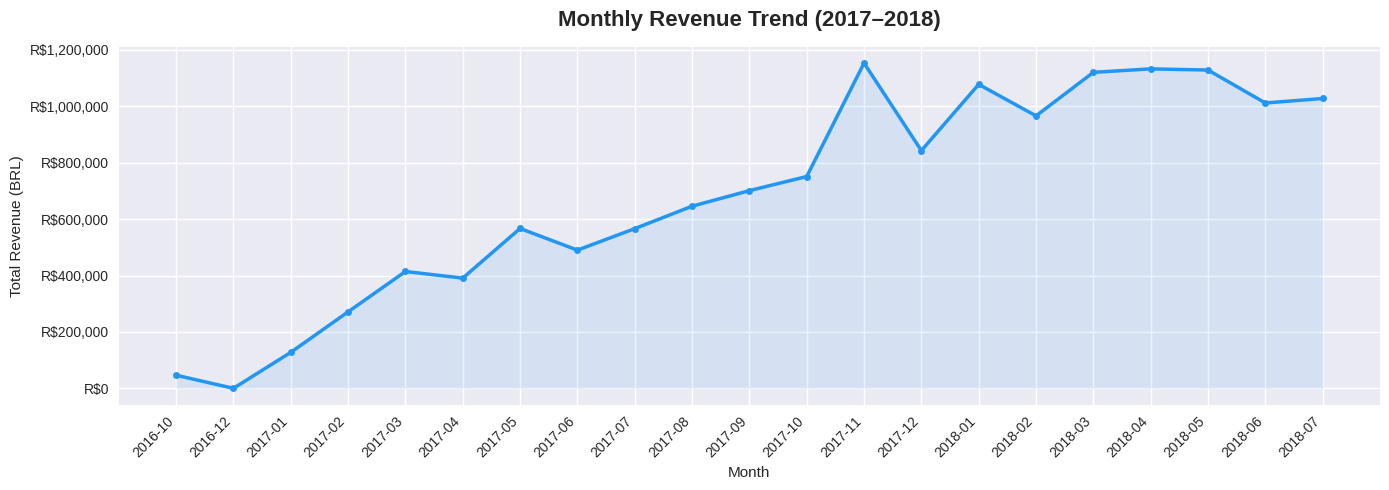

Chart 1 saved!
📌 Peak month: 2017-11 — R$1,153,364


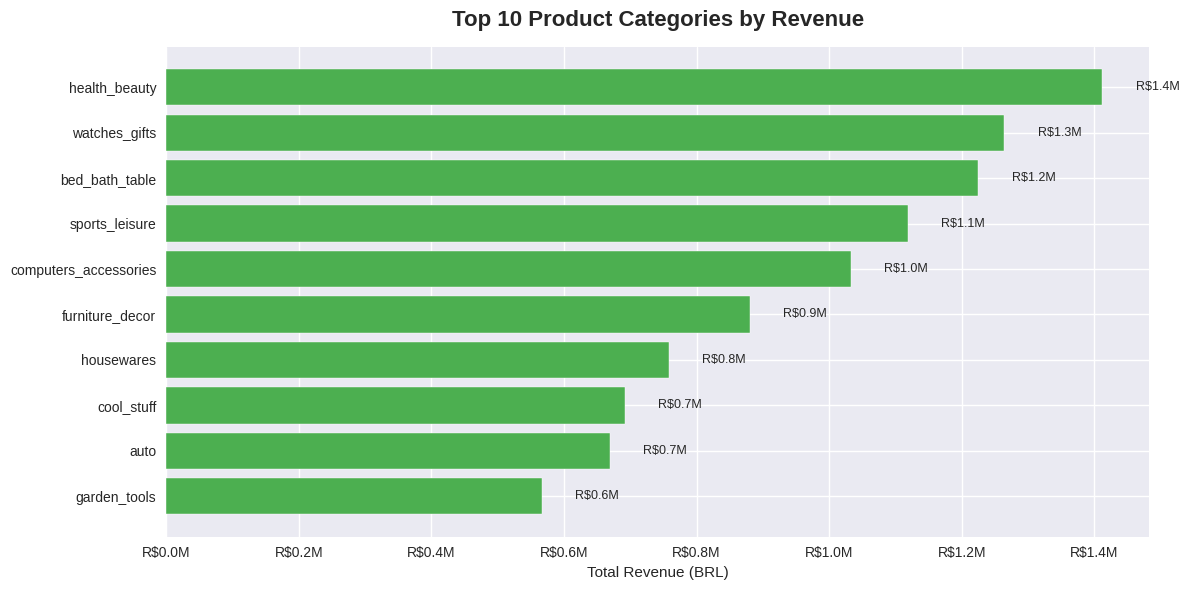

Chart 2 saved!


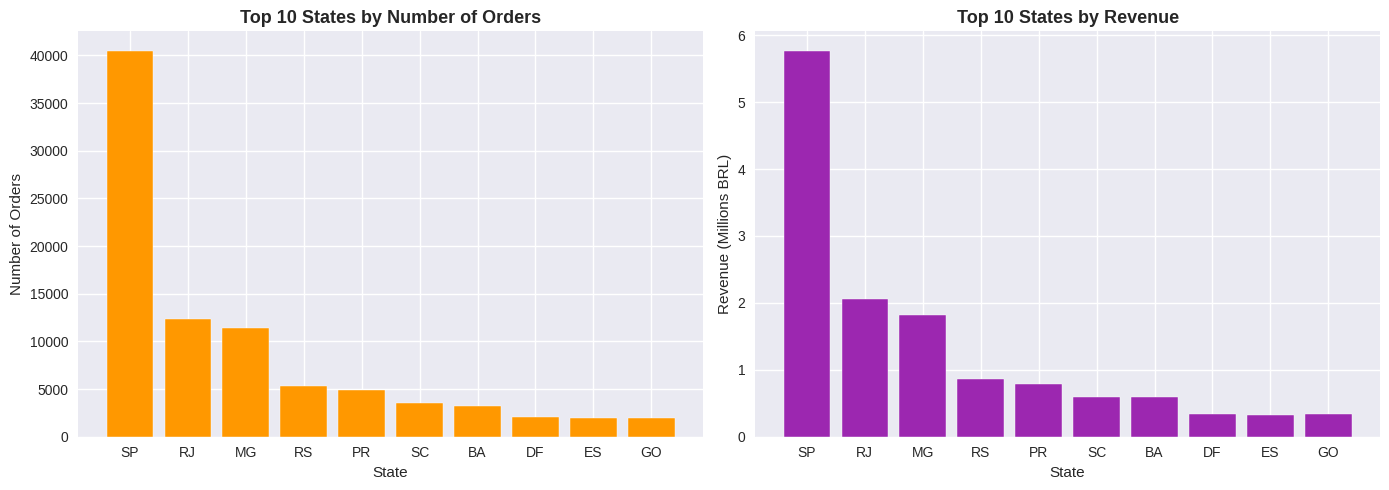

Chart 3 saved!


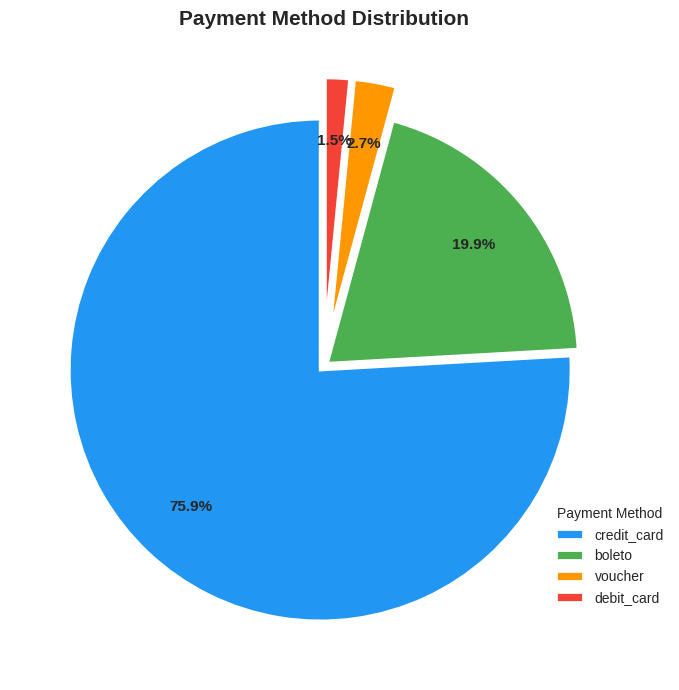

Chart 4 saved!


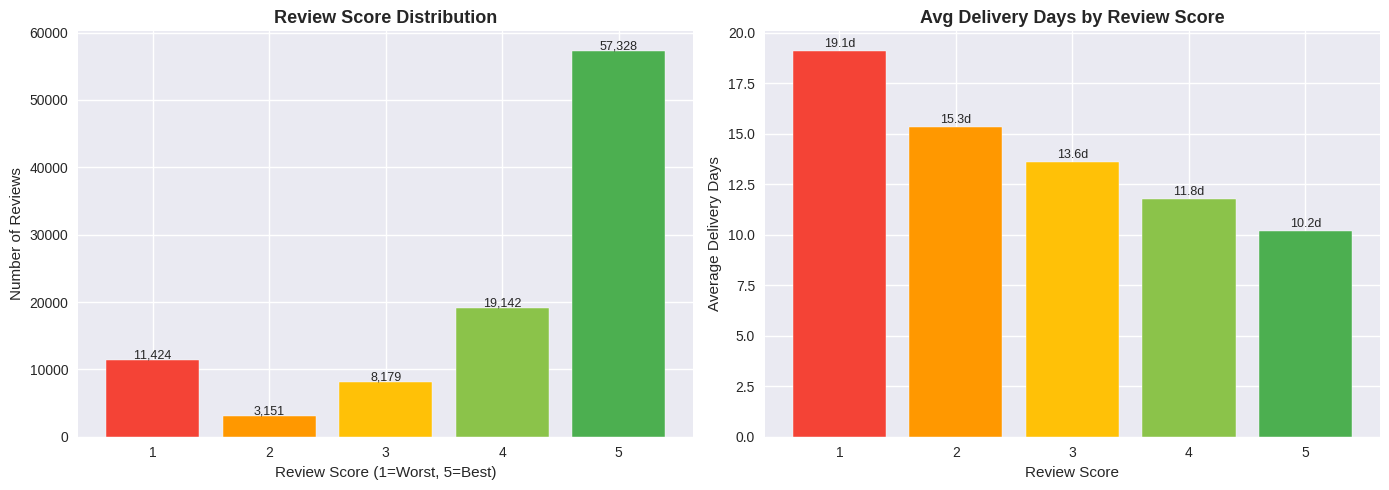

Chart 5 saved!


In [22]:
# PHASE 3: ANALYSIS & VISUALIZATIONS

# ---- Q1: How did monthly revenue trend over time? ----
# Concept: groupby() groups rows by a column, then we aggregate
# Here we group by month and sum up all revenue (price + freight)

df['revenue'] = df['price'] + df['freight_value']

monthly_revenue = (
    df.groupby('order_month')['revenue']
    .sum()
    .reset_index()
)
monthly_revenue['order_month'] = monthly_revenue['order_month'].astype(str)

# Remove first and last month (often incomplete data)
monthly_revenue = monthly_revenue.iloc[1:-1]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly_revenue['order_month'], monthly_revenue['revenue'],
        marker='o', linewidth=2.5, color='#2196F3', markersize=5)
ax.fill_between(range(len(monthly_revenue)), monthly_revenue['revenue'], alpha=0.1, color='#2196F3')
ax.set_xticks(range(len(monthly_revenue)))
ax.set_xticklabels(monthly_revenue['order_month'], rotation=45, ha='right')
ax.set_title('Monthly Revenue Trend (2017–2018)', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Month')
ax.set_ylabel('Total Revenue (BRL)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'R${x:,.0f}'))
plt.tight_layout()
plt.savefig('01_monthly_revenue_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 1 saved!")

# Find peak month
peak = monthly_revenue.loc[monthly_revenue['revenue'].idxmax()]
print(f"📌 Peak month: {peak['order_month']} — R${peak['revenue']:,.0f}")

# ---- Q2: What are the Top 10 Product Categories by Revenue? ----
# We fill missing category names before grouping

df['product_category_name_english'] = df['product_category_name_english'].fillna('Unknown')

category_revenue = (
    df.groupby('product_category_name_english')['revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(category_revenue['product_category_name_english'][::-1],
               category_revenue['revenue'][::-1], color='#4CAF50', edgecolor='white')

# Add value labels on bars
for bar, val in zip(bars, category_revenue['revenue'][::-1]):
    ax.text(bar.get_width() + 50000, bar.get_y() + bar.get_height()/2,
            f'R${val/1e6:.1f}M', va='center', fontsize=9)

ax.set_title('Top 10 Product Categories by Revenue', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Total Revenue (BRL)')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'R${x/1e6:.1f}M'))
plt.tight_layout()
plt.savefig('02_top_categories.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 2 saved!")

# ---- Q3: Customer Segmentation by State (Top 10) ----
# Which states generate the most orders?

state_orders = (
    df.groupby('customer_state')
    .agg(total_orders=('order_id', 'nunique'),
         total_revenue=('revenue', 'sum'))
    .sort_values('total_orders', ascending=False)
    .head(10)
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Orders by state
axes[0].bar(state_orders['customer_state'], state_orders['total_orders'],
            color='#FF9800', edgecolor='white')
axes[0].set_title('Top 10 States by Number of Orders', fontsize=13, fontweight='bold')
axes[0].set_xlabel('State')
axes[0].set_ylabel('Number of Orders')

# Revenue by state
axes[1].bar(state_orders['customer_state'], state_orders['total_revenue']/1e6,
            color='#9C27B0', edgecolor='white')
axes[1].set_title('Top 10 States by Revenue', fontsize=13, fontweight='bold')
axes[1].set_xlabel('State')
axes[1].set_ylabel('Revenue (Millions BRL)')

plt.tight_layout()
plt.savefig('03_customer_states.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 3 saved!")

# ---- Q4: Payment Method Distribution ----

payment_dist = (
    df.groupby('payment_type')['order_id']
    .nunique()
    .sort_values(ascending=False)
    .reset_index()
)
payment_dist.columns = ['payment_type', 'order_count']

colors = ['#2196F3', '#4CAF50', '#FF9800', '#F44336', '#9C27B0']

fig, ax = plt.subplots(figsize=(9, 7))

explode = [0.02 if v/sum(payment_dist['order_count']) > 0.05 else 0.15
           for v in payment_dist['order_count']]

wedges, texts, autotexts = ax.pie(
    payment_dist['order_count'],
    labels=None,
    autopct='%1.1f%%',
    colors=colors[:len(payment_dist)],
    startangle=90,
    explode=explode,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    pctdistance=0.75
)

for text in autotexts:
    text.set_fontsize(11)
    text.set_fontweight('bold')

ax.legend(
    wedges,
    payment_dist['payment_type'],
    title="Payment Method",
    loc="lower left",
    bbox_to_anchor=(0.85, 0.1),
    fontsize=10
)
ax.set_title('Payment Method Distribution', fontsize=15, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('04_payment_methods.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 4 saved!")

# ---- Q5: Review Score Distribution + Delivery Time vs Score ----

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Review score counts
review_counts = reviews['review_score'].value_counts().sort_index()
colors_review = ['#F44336', '#FF9800', '#FFC107', '#8BC34A', '#4CAF50']
axes[0].bar(review_counts.index, review_counts.values, color=colors_review, edgecolor='white')
axes[0].set_title('Review Score Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Review Score (1=Worst, 5=Best)')
axes[0].set_ylabel('Number of Reviews')
for i, (score, count) in enumerate(zip(review_counts.index, review_counts.values)):
    axes[0].text(score, count + 200, f'{count:,}', ha='center', fontsize=9)

# Avg delivery time by review score
delivery_vs_review = (
    df.merge(reviews[['order_id', 'review_score']], on='order_id', how='left')
    .groupby('review_score')['delivery_days']
    .mean()
    .reset_index()
)
axes[1].bar(delivery_vs_review['review_score'], delivery_vs_review['delivery_days'],
            color=colors_review, edgecolor='white')
axes[1].set_title('Avg Delivery Days by Review Score', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Review Score')
axes[1].set_ylabel('Average Delivery Days')
for _, row in delivery_vs_review.iterrows():
    axes[1].text(row['review_score'], row['delivery_days'] + 0.2,
                 f"{row['delivery_days']:.1f}d", ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('05_reviews_delivery.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 5 saved!")

In [ ]:
# PHASE 4: INSIGHTS SUMMARY

summary = """
╔══════════════════════════════════════════════════════════════════╗
║         OLIST E-COMMERCE: EDA INSIGHTS SUMMARY                   ║
║         Dataset: 99,441 orders | 2016–2018 | Brazil              ║
╚══════════════════════════════════════════════════════════════════╝

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
INSIGHT 1: Strong Business Growth with Seasonal Peaks
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Finding   : Revenue grew ~10x from Oct 2016 (R$75K) to Nov 2017 (R$1.17M).
            A sharp spike in Nov 2017 suggests a Black Friday / promotional event.
            Revenue stabilized around R$1M/month through 2018.
Impact    : Business is scaling rapidly. The Nov spike shows promotions work.
Action    : Invest in pre-Black Friday inventory & marketing.
            Plan logistics capacity for Q4 demand surge.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
INSIGHT 2: Health & Beauty Dominates — Lifestyle Categories Lead
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Finding   : Top 3 categories — health_beauty (R$1.4M), watches_gifts (R$1.3M),
            bed_bath_table (R$1.2M) — are all personal/lifestyle products.
            Top 10 categories together account for the majority of revenue.
Impact    : Consumer demand is heavily lifestyle-oriented, not electronics/tech.
Action    : Prioritize supplier deals and promotions in these top 3 categories.
            Consider bundling (e.g., health + beauty combos) to increase basket size.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
INSIGHT 3: São Paulo Drives ~42% of All Orders
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Finding   : SP accounts for ~40,000 orders and ~R$5.8M revenue —
            roughly 3x more than the next state (RJ at ~12,500 orders).
            The top 3 states (SP, RJ, MG) represent ~70% of total volume.
Impact    : Heavy geographic concentration creates both opportunity and risk.
Action    : Strengthen logistics hubs in SP/RJ/MG for faster delivery.
            Launch targeted campaigns in mid-tier states (RS, PR, SC)
            to diversify revenue and reduce concentration risk.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
INSIGHT 4: Credit Card is King — Installments are Key
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Finding   : 75.9% of orders paid by credit card.
            19.9% use boleto (Brazil bank slip — typically lower income buyers).
            Only 1.5% debit card, 2.7% voucher.
Impact    : Customers prefer credit — likely using installments for larger purchases.
Action    : Offer "0% installment" promotions on high-ticket categories
            (watches, computers) to boost conversion.
            Improve boleto experience to capture the 20% segment better.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
INSIGHT 5: Delivery Speed Directly Drives Customer Satisfaction
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Finding   : Avg delivery for 5-star reviews = 10.2 days
            Avg delivery for 1-star reviews = 19.1 days
            That's a 9-day difference between happy and unhappy customers.
            11,424 orders received 1-star — a significant churn risk.
Impact    : Slow delivery is the #1 driver of negative reviews.
            Negative reviews damage seller reputation and future sales.
Action    : Set a delivery SLA target of under 12 days for all orders.
            Prioritize same-region warehousing to reduce transit time.
            Flag orders approaching day 15 for proactive customer communication.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
KEY METRICS AT A GLANCE
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Total Delivered Orders : 96,478
  Avg Delivery Time      : 12.1 days
  Top Category           : Health & Beauty (R$1.4M)
  Top State              : São Paulo (42% of orders)
  Dominant Payment       : Credit Card (75.9%)
  % 5-Star Reviews       : ~57% of all reviews
  % 1-Star Reviews       : ~11% of all reviews (needs improvement)
"""

print(summary)


╔══════════════════════════════════════════════════════════════════╗
║         OLIST E-COMMERCE: EDA INSIGHTS SUMMARY                   ║
║         Dataset: 99,441 orders | 2016–2018 | Brazil              ║
╚══════════════════════════════════════════════════════════════════╝

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
INSIGHT 1: Strong Business Growth with Seasonal Peaks
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Finding   : Revenue grew ~10x from Oct 2016 (R$75K) to Nov 2017 (R$1.17M).
            A sharp spike in Nov 2017 suggests a Black Friday / promotional event.
            Revenue stabilized around R$1M/month through 2018.
Impact    : Business is scaling rapidly. The Nov spike shows promotions work.
Action    : Invest in pre-Black Friday inventory & marketing. 
            Plan logistics capacity for Q4 demand surge.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
INSIGHT 2: Health & Beauty Dominates — Lifestyle Categories Lead
━━━━━━━━━━━━━━━━━━━━━━━━━━━